# Fuzzy-Logic Driving Strategy - Full 4-Lap Attempt
### SEM Hydrogen Urban Concept - two-motor powertrain + new **SZFC-1000** fuel cell

This notebook derives a complete driving strategy from a small **fuzzy rulebook** over the road ahead, then runs it through the validated digital-twin physics for the whole four-lap attempt. It answers, for every metre of track:

- **where to GAS vs where to GLIDE** (pulse-and-glide),
- **which of the two motors** to use (accel vs cruise),
- the resulting **speed, hydrogen burn and Art. 54e efficiency**.

The fuzzy rules: *climb -> hold a slower target (do not burn H2 fighting gravity); flat -> eco cruise; descend -> cut the motor early and glide (gravity is free speed); corner/stop -> the safety ceiling caps us.* The strategy is tuned for the **most efficient run that still finishes inside the 35-minute limit**.

In [1]:
import os, sys
# run from the repo root so `from digital_twin import ...` and data/ paths resolve
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'digital_twin')):
    root = os.path.dirname(root)
os.chdir(root); sys.path.insert(0, root)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
from IPython.display import display
%matplotlib inline

from digital_twin import config, track as tmod, simulate as sim, weather as wmod
from digital_twin import powertrain as pt, strategy_analysis as sa

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 120, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#ececea', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#9a9a95', 'font.size': 11.5,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 12, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': '#3a3a38', 'ytick.color': '#3a3a38', 'legend.fontsize': 10,
})

# RACING-LINE profile -- same backbone optimize_ga/optimize_cma use (apples-to-apples)
profile = tmod.build_racing_line_profile(save=False)
full = sim.build_full_attempt_track(profile)
scenario = wmod.SCENARIOS['typical_january']
motors = pt.load_motors()
accel_motor = motors[config.ACCEL_MOTOR_NAME]
cruise_motor = motors[config.CRUISE_MOTOR_NAME]
fc = pt.load_fuel_cells()[config.DEFAULT_FC_NAME]
cruise_converter = pt.load_converters()[config.CRUISE_CONVERTER_NAME]  # teammate's DC-DC (Querom)
print('Track      :', len(full), 'points |', round(full.s_m.iloc[-1] / 1000, 2), 'km |', full.lap.nunique(), 'laps (racing line)')
print('Accel motor:', accel_motor.name, '(peak', round(accel_motor.max_mech_power_w()), 'W)')
print('Cruise mtr :', cruise_motor.name, '(peak', round(cruise_motor.max_mech_power_w()), 'W)')
print('Fuel cell  :', fc.name, '(rated', fc.rated_power_w, 'W) <-- new SZFC-1000')
print('Weather    :', scenario.name)
from digital_twin import fuzzy_strategy as fz
TITLE = 'Fuzzy'


powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
Track      : 2936 points | 14.5 km | 4 laps (racing line)
Accel motor: BLDC 650W (peak 953 W)
Cruise mtr : BG 42x30 dCore (peak 156 W)
Fuel cell  : SZFC-1000 (rated 1000 W) <-- new SZFC-1000
Weather    : typical_january


## 1 - The fuzzy rulebook
The membership functions (left) turn the grade ahead into DOWN/FLAT/UP degrees; the rules (right) blend those into a gas target and a glide floor.

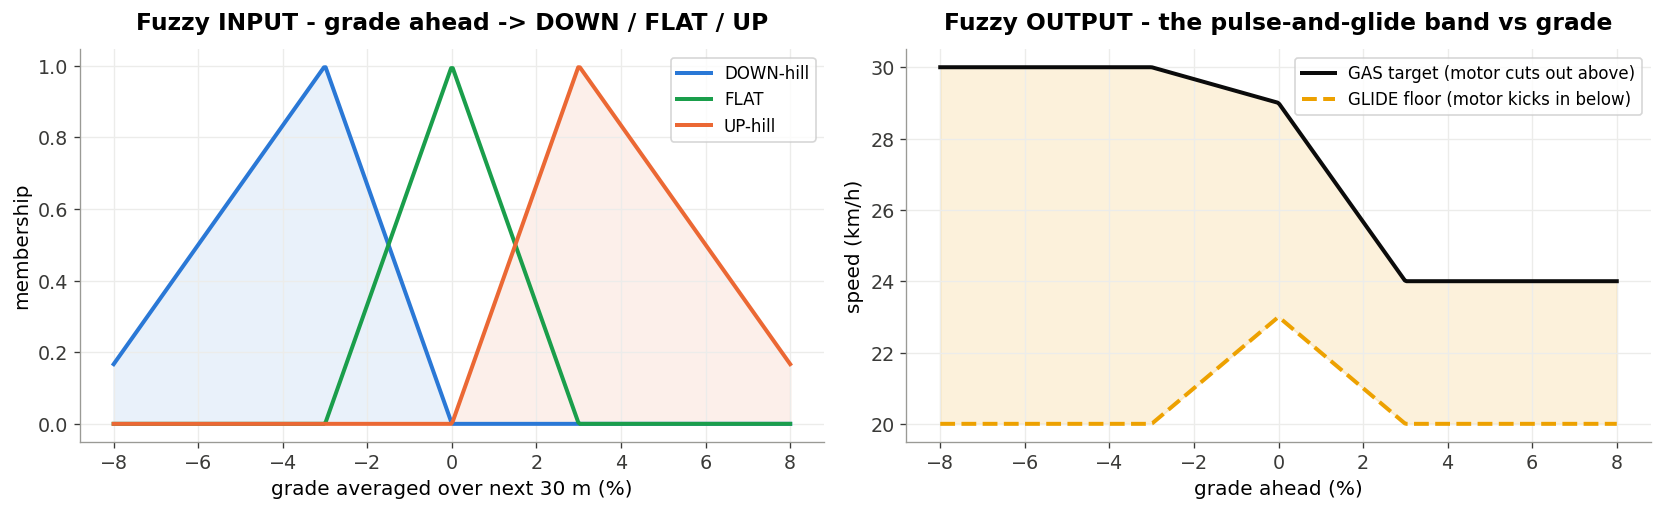

In [2]:
strat0 = fz.FuzzyStrategy()
g = np.linspace(-8, 8, 400)
mu_down, mu_flat, mu_up = strat0._memberships(g)
wsum = np.clip(mu_down + mu_flat + mu_up, 1e-9, None)
v_target_curve = (mu_down * strat0.v_fast + mu_flat * strat0.v_med + mu_up * strat0.v_slow) / wsum
band_curve = (mu_down * strat0.band_down + mu_flat * strat0.band_flat + mu_up * strat0.band_up) / wsum
v_coast_curve = v_target_curve - band_curve

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4.4))
axA.plot(g, mu_down, color='#2a78d6', lw=2.4, label='DOWN-hill')
axA.plot(g, mu_flat, color='#1a9e4b', lw=2.4, label='FLAT')
axA.plot(g, mu_up, color='#eb6834', lw=2.4, label='UP-hill')
axA.fill_between(g, mu_down, color='#2a78d6', alpha=0.10); axA.fill_between(g, mu_up, color='#eb6834', alpha=0.10)
axA.set_title('Fuzzy INPUT - grade ahead -> DOWN / FLAT / UP')
axA.set_xlabel('grade averaged over next 30 m (%)'); axA.set_ylabel('membership'); axA.legend()
axB.plot(g, v_target_curve, color='#0b0b0b', lw=2.4, label='GAS target (motor cuts out above)')
axB.plot(g, v_coast_curve, color='#eda100', lw=2.4, ls='--', label='GLIDE floor (motor kicks in below)')
axB.fill_between(g, v_coast_curve, v_target_curve, color='#eda100', alpha=0.14)
axB.set_title('Fuzzy OUTPUT - the pulse-and-glide band vs grade')
axB.set_xlabel('grade ahead (%)'); axB.set_ylabel('speed (km/h)'); axB.legend()
plt.tight_layout(); plt.show()


## 2 - Tuning for the most efficient feasible strategy
Each point is a full 4-lap run. We keep the highest-scoring one that stays under 35 minutes with zero rule violations.

,distance_km,time_min,h2_l,score_km_per_m3,time_ok,rule_violations,v_med,band,feasible
0,14.5,39.62,44.11,286.07,False,0,27,8,False
1,14.5,37.61,45.77,278.79,False,0,27,6,False
2,14.5,38.02,45.84,278.03,False,0,28,8,False
3,14.5,36.15,47.02,273.48,False,0,28,6,False
4,14.5,36.06,47.49,271.18,False,0,27,5,False
5,14.5,36.45,47.93,268.62,False,0,29,8,False
6,14.5,34.81,48.73,266.06,True,0,29,6,True
7,14.5,34.76,49.27,263.46,True,0,28,5,True
8,14.5,35.10,49.57,261.78,False,0,30,8,False
9,14.5,33.67,50.41,258.94,True,0,30,6,True


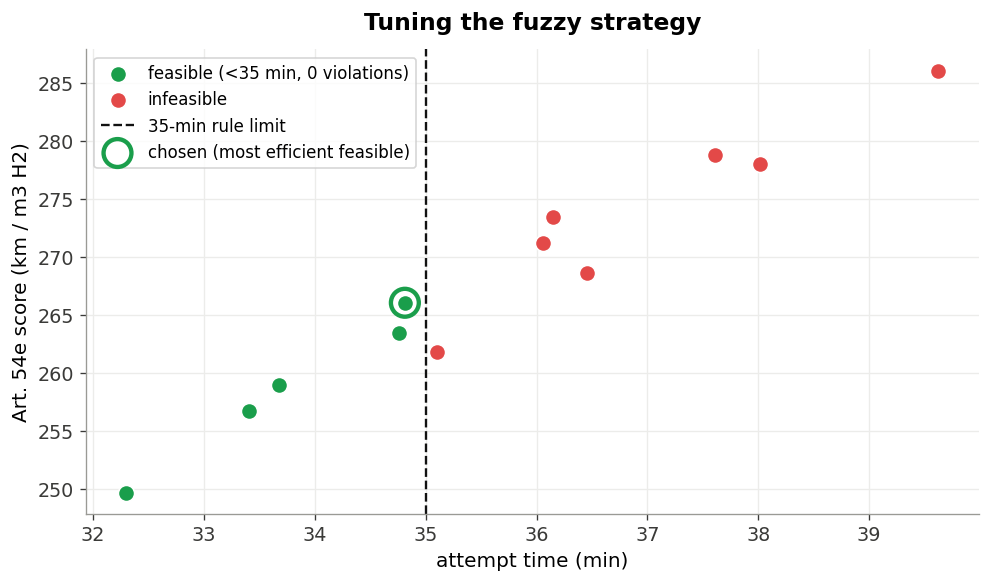

Chosen fuzzy knobs: v_med = 29 km/h | band = 6 km/h


In [3]:
# Tune the two knobs that most move the H2-vs-time trade-off, keep the best FEASIBLE
# run (<=35 min, 0 rule violations) -> the most efficient strategy that still finishes legally.
best_strat, best_result, grid = fz.tune_grid(full, scenario, accel_motor, cruise_motor, fc, verbose=False, cruise_converter=cruise_converter)
grid['feasible'] = grid.time_ok & (grid.rule_violations == 0)
display(grid.sort_values('score_km_per_m3', ascending=False).round(2).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8.4, 5))
for feas, c, lab in [(True, '#1a9e4b', 'feasible (<35 min, 0 violations)'), (False, '#e34948', 'infeasible')]:
    m = grid.feasible == feas
    ax.scatter(grid.time_min[m], grid.score_km_per_m3[m], s=95, c=c, edgecolor='white', label=lab, zorder=3)
ax.axvline(config.MAX_ATTEMPT_TIME_MIN, color='#111111', ls='--', lw=1.4, label='35-min rule limit')
ax.scatter([best_result['time_min']], [best_result['score_km_per_m3']], s=280, facecolor='none',
           edgecolor='#1a9e4b', lw=2.6, zorder=4, label='chosen (most efficient feasible)')
ax.set_xlabel('attempt time (min)'); ax.set_ylabel('Art. 54e score (km / m3 H2)')
ax.set_title('Tuning the fuzzy strategy'); ax.legend(); plt.tight_layout(); plt.show()
print('Chosen fuzzy knobs: v_med =', best_result['v_med'], 'km/h | band =', best_result['band'], 'km/h')


## 3 - Run the chosen strategy over the whole attempt

In [4]:
tel = fz.run(full, scenario, accel_motor, cruise_motor, fc, best_strat, cruise_converter=cruise_converter)
df = sa.enrich(tel)
df.to_csv(os.path.join('notebooks', 'fuzzy', 'fuzzy_attempt_analysis.csv'), index=False)
S = sa.summary(tel, 'Fuzzy')
print('=== FUZZY STRATEGY -- whole 4-lap attempt (two-motor + SZFC-1000) ===')
for k, v in S.items():
    print(f'{k:18}: {v}')


=== FUZZY STRATEGY -- whole 4-lap attempt (two-motor + SZFC-1000) ===
strategy          : Fuzzy
distance_km       : 14.501
time_min          : 34.92
avg_speed_kmh     : 24.92
h2_litres         : 48.73
score_km_per_m3   : 266.1
gas_pct           : 27.6
glide_pct         : 72.0
brake_pct         : 0.3
accel_motor_pct   : 27.3
cruise_motor_pct  : 72.7
time_ok           : True
rule_violations   : 0


In [5]:
# shared colours + a stop/start marker helper for every track map
ymax = df.v_kmh.max() * 1.05
PHASE_COLORS = sa.PHASE_COLORS          # gas=green, glide=amber, brake=red
MOTOR_COLORS = sa.MOTOR_COLORS
PHASE_LABEL = {'gas': 'GAS - motor ON (accelerating)',
               'glide': 'GLIDE - motor OFF (coasting)', 'brake': 'BRAKE'}
MOTOR_LABEL = {accel_motor.name: accel_motor.name + '  -  acceleration motor',
               cruise_motor.name: cruise_motor.name + '  -  cruise motor'}
ev = sa.event_xy(df)

def mark_stops(ax, annotate=True):
    sfx, sfy = ev['start_finish']; s1 = ev['stop-and-go 1']; s2 = ev['stop-and-go 2']
    ax.scatter(*s2, s=430, marker='*', facecolor='#111111', edgecolor='white', lw=1.4, zorder=9)
    ax.scatter(sfx, sfy, s=360, marker='s', facecolor='#0d47a1', edgecolor='white', lw=1.6, zorder=10)
    ax.scatter(s1[0], s1[1] + 90, s=430, marker='*', facecolor='#6a3d9a', edgecolor='white', lw=1.4, zorder=11)
    ax.plot([sfx, s1[0]], [sfy, s1[1] + 90], color='#6a3d9a', lw=1.0, ls=':', zorder=8)
    if annotate:
        ax.annotate('START / FINISH', (sfx, sfy), textcoords='offset points', xytext=(12, -14),
                    fontsize=9.5, fontweight='bold', color='#0d47a1')
        ax.annotate('STOP-AND-GO 1', (s1[0], s1[1] + 90), textcoords='offset points', xytext=(12, 4),
                    fontsize=9.5, fontweight='bold', color='#6a3d9a')
        ax.annotate('STOP-AND-GO 2', s2, textcoords='offset points', xytext=(12, 3),
                    fontsize=9.5, fontweight='bold', color='#111111')

STOP_HANDLES = [
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#0d47a1', markeredgecolor='white', markersize=13, label='start / finish'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='#6a3d9a', markeredgecolor='white', markersize=15, label='stop-and-go 1'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='#111111', markeredgecolor='white', markersize=15, label='stop-and-go 2'),
]

# one representative lap (lap 2 -- has both stop-and-gos) for the detailed views
steady = df[df.lap == 2].copy()
sg2_lapkm = steady.loc[steady.stop_label == 'stop-and-go 2', 'lap_distance_km']
sg2_lapkm = float(sg2_lapkm.iloc[0]) if len(sg2_lapkm) else None
print('steady lap =', 2, '|', len(steady), 'points | phases:', steady.drive_phase.value_counts().to_dict())


steady lap = 2 | 734 points | phases: {'glide': 531, 'gas': 200, 'brake': 3}


## 4 - Whole-attempt speed overview
All four laps end to end, with the compulsory stop-and-gos marked.

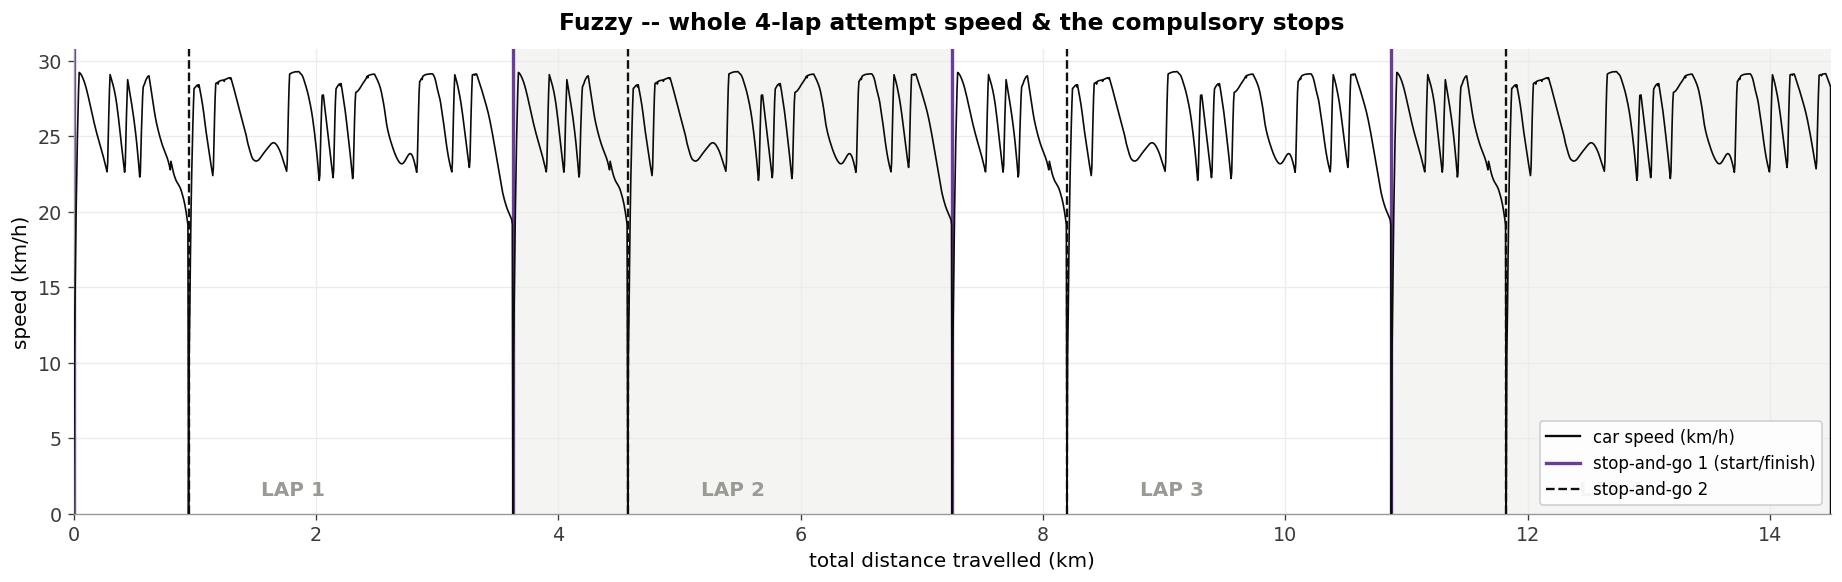

In [6]:
fig, ax = plt.subplots(figsize=(15.5, 5))
for lap in sorted(df.lap.unique()):
    seg = df[df.lap == lap]
    if lap % 2 == 0:
        ax.axvspan(seg.distance_km.min(), seg.distance_km.max(), color='#f4f4f2', zorder=0)
    ax.text((seg.distance_km.min() + seg.distance_km.max()) / 2, ymax * 0.04, 'LAP ' + str(lap),
            ha='center', fontsize=12, fontweight='bold', color='#9a9a95')
ax.plot(df.distance_km, df.v_kmh, color='#0b0b0b', lw=1.0, zorder=3)
for _, r in df[df.stop_label == 'stop-and-go 1'].iterrows():
    ax.axvline(r.distance_km, color='#6a3d9a', lw=2.0)
for _, r in df[df.stop_label == 'stop-and-go 2'].iterrows():
    ax.axvline(r.distance_km, color='#111111', ls='--', lw=1.4)
ax.set_xlim(0, df.distance_km.max()); ax.set_ylim(0, ymax)
ax.set_xlabel('total distance travelled (km)'); ax.set_ylabel('speed (km/h)')
ax.set_title(TITLE + ' -- whole 4-lap attempt speed & the compulsory stops')
ax.legend(handles=[Line2D([0], [0], color='#0b0b0b', lw=1.4, label='car speed (km/h)'),
                   Line2D([0], [0], color='#6a3d9a', lw=2.0, label='stop-and-go 1 (start/finish)'),
                   Line2D([0], [0], color='#111111', ls='--', lw=1.4, label='stop-and-go 2')],
          loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()


## Track maps - which motor & how fast (steady lap)
Geo-accurate maps of the Lusail lap. Left: which motor drives each part. Right: speed heatmap.

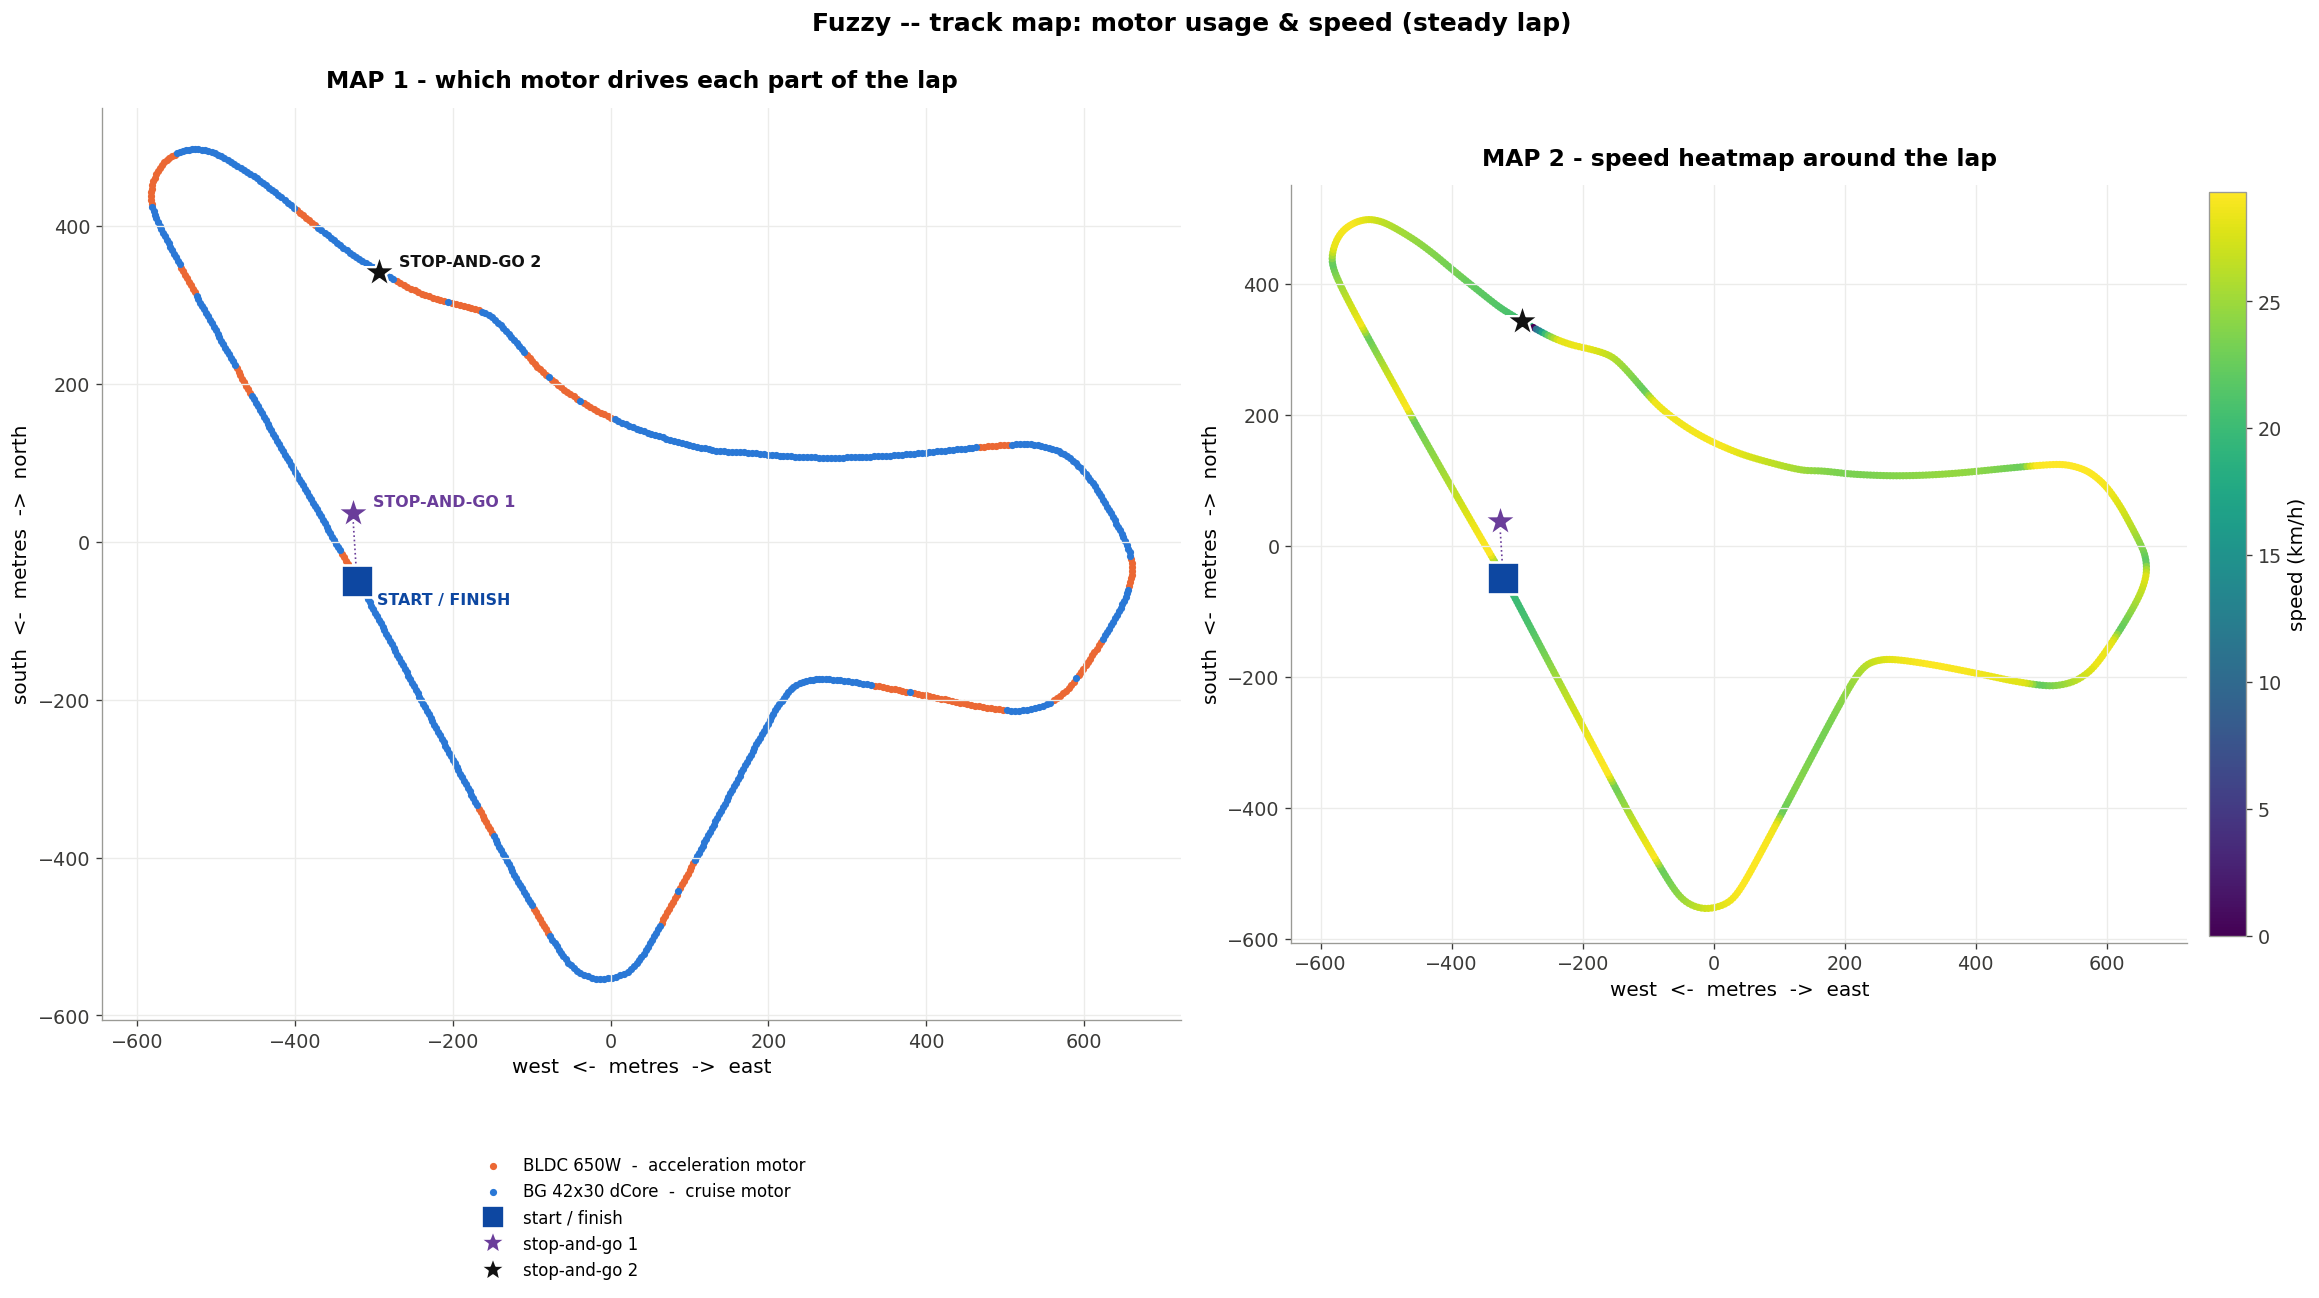

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9.5))  # larger, true geometry (equal aspect)
for name, c in MOTOR_COLORS.items():
    m = steady.active_motor == name
    ax1.scatter(steady.x_m[m], steady.y_m[m], s=11, c=c, label=MOTOR_LABEL.get(name, name))
mark_stops(ax1)
ax1.set_aspect('equal'); ax1.set_title('MAP 1 - which motor drives each part of the lap')
ax1.set_xlabel('west  <-  metres  ->  east'); ax1.set_ylabel('south  <-  metres  ->  north')
h, l = ax1.get_legend_handles_labels()
ax1.legend(h + STOP_HANDLES, l + [x.get_label() for x in STOP_HANDLES],
           loc='lower center', bbox_to_anchor=(0.5, -0.30), frameon=False)

sc = ax2.scatter(steady.x_m, steady.y_m, s=11, c=steady.v_kmh, cmap='viridis')
mark_stops(ax2, annotate=False)
ax2.set_aspect('equal'); ax2.set_title('MAP 2 - speed heatmap around the lap')
ax2.set_xlabel('west  <-  metres  ->  east'); ax2.set_ylabel('south  <-  metres  ->  north')
cb = fig.colorbar(sc, ax=ax2, shrink=0.8, pad=0.02); cb.set_label('speed (km/h)')
fig.suptitle(TITLE + ' -- track map: motor usage & speed (steady lap)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Track map - where to GAS vs GLIDE
Green = motor powering; amber = coasting motor-off; red = braking.

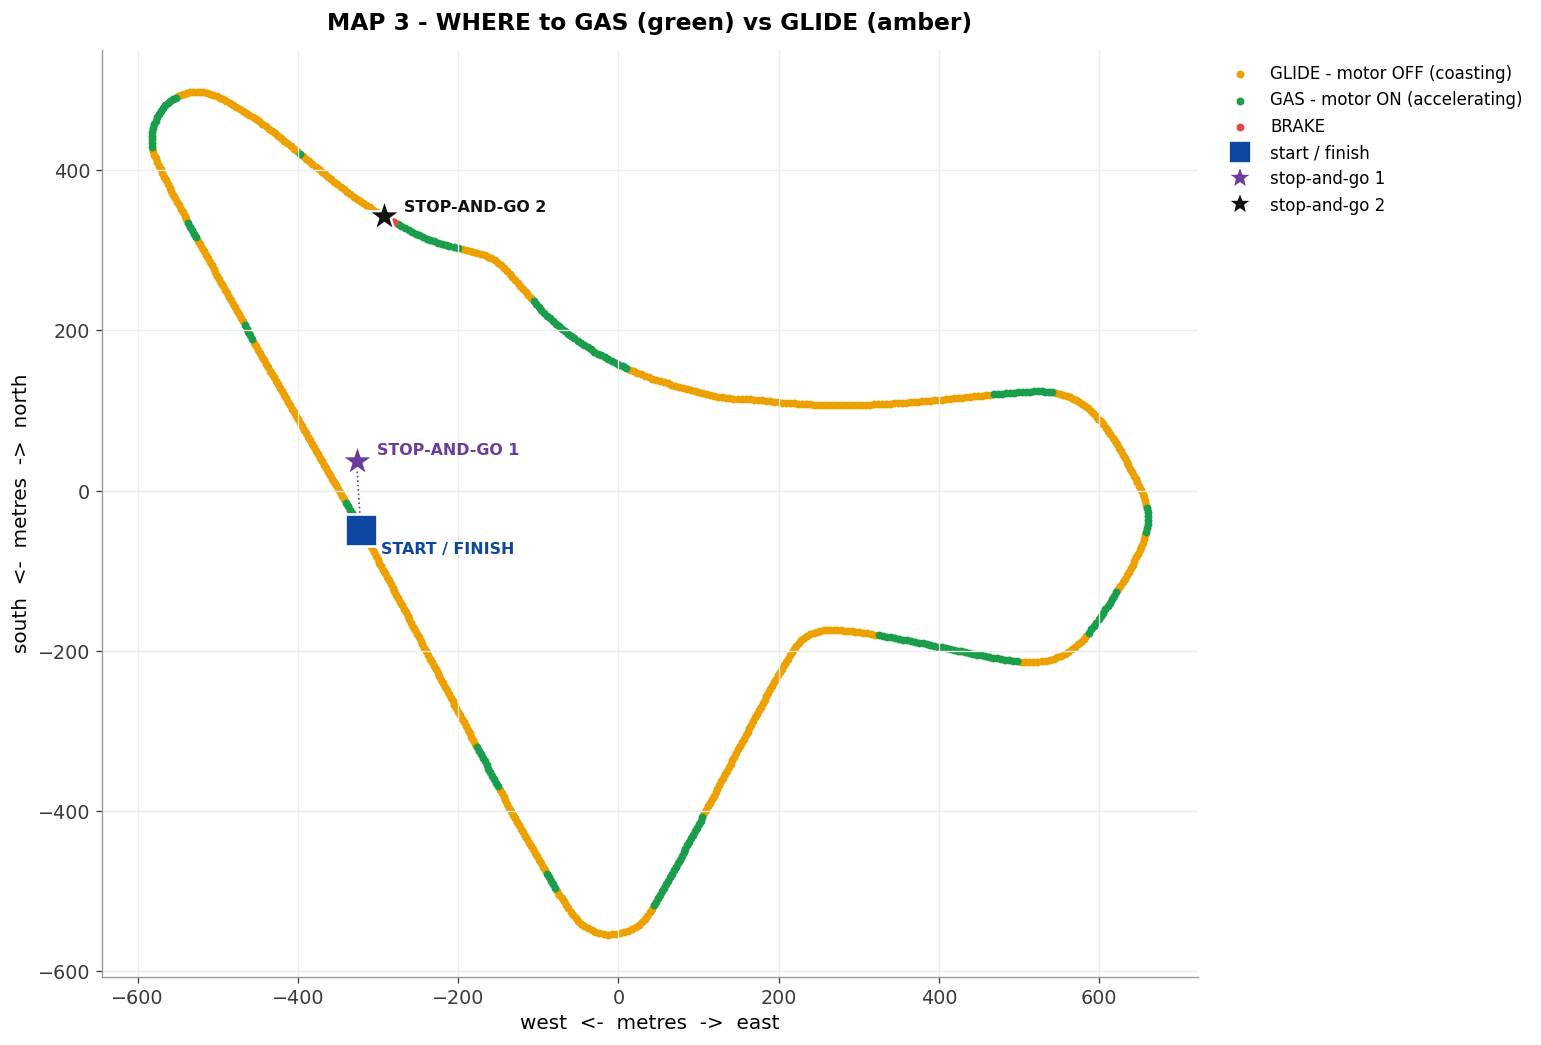

In [8]:
fig, ax = plt.subplots(figsize=(13, 11.5))  # larger, true geometry (equal aspect)
for ph in ['glide', 'gas', 'brake']:
    m = steady.drive_phase == ph
    if m.any():
        ax.scatter(steady.x_m[m], steady.y_m[m], s=14, c=PHASE_COLORS[ph], label=PHASE_LABEL[ph])
mark_stops(ax)
ax.set_aspect('equal')
ax.set_title('MAP 3 - WHERE to GAS (green) vs GLIDE (amber)')
ax.set_xlabel('west  <-  metres  ->  east'); ax.set_ylabel('south  <-  metres  ->  north')
h, l = ax.get_legend_handles_labels()
ax.legend(h + STOP_HANDLES, l + [x.get_label() for x in STOP_HANDLES],
          loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
plt.tight_layout(); plt.show()


## The driver heatmap - the whole lap at a glance
One stacked strip per channel, sharing the lap-distance axis: **speed, the gas/glide command, which motor, road grade, and hydrogen burn**. This is the single view a driver (or the strategy engineer) reads off during the run.

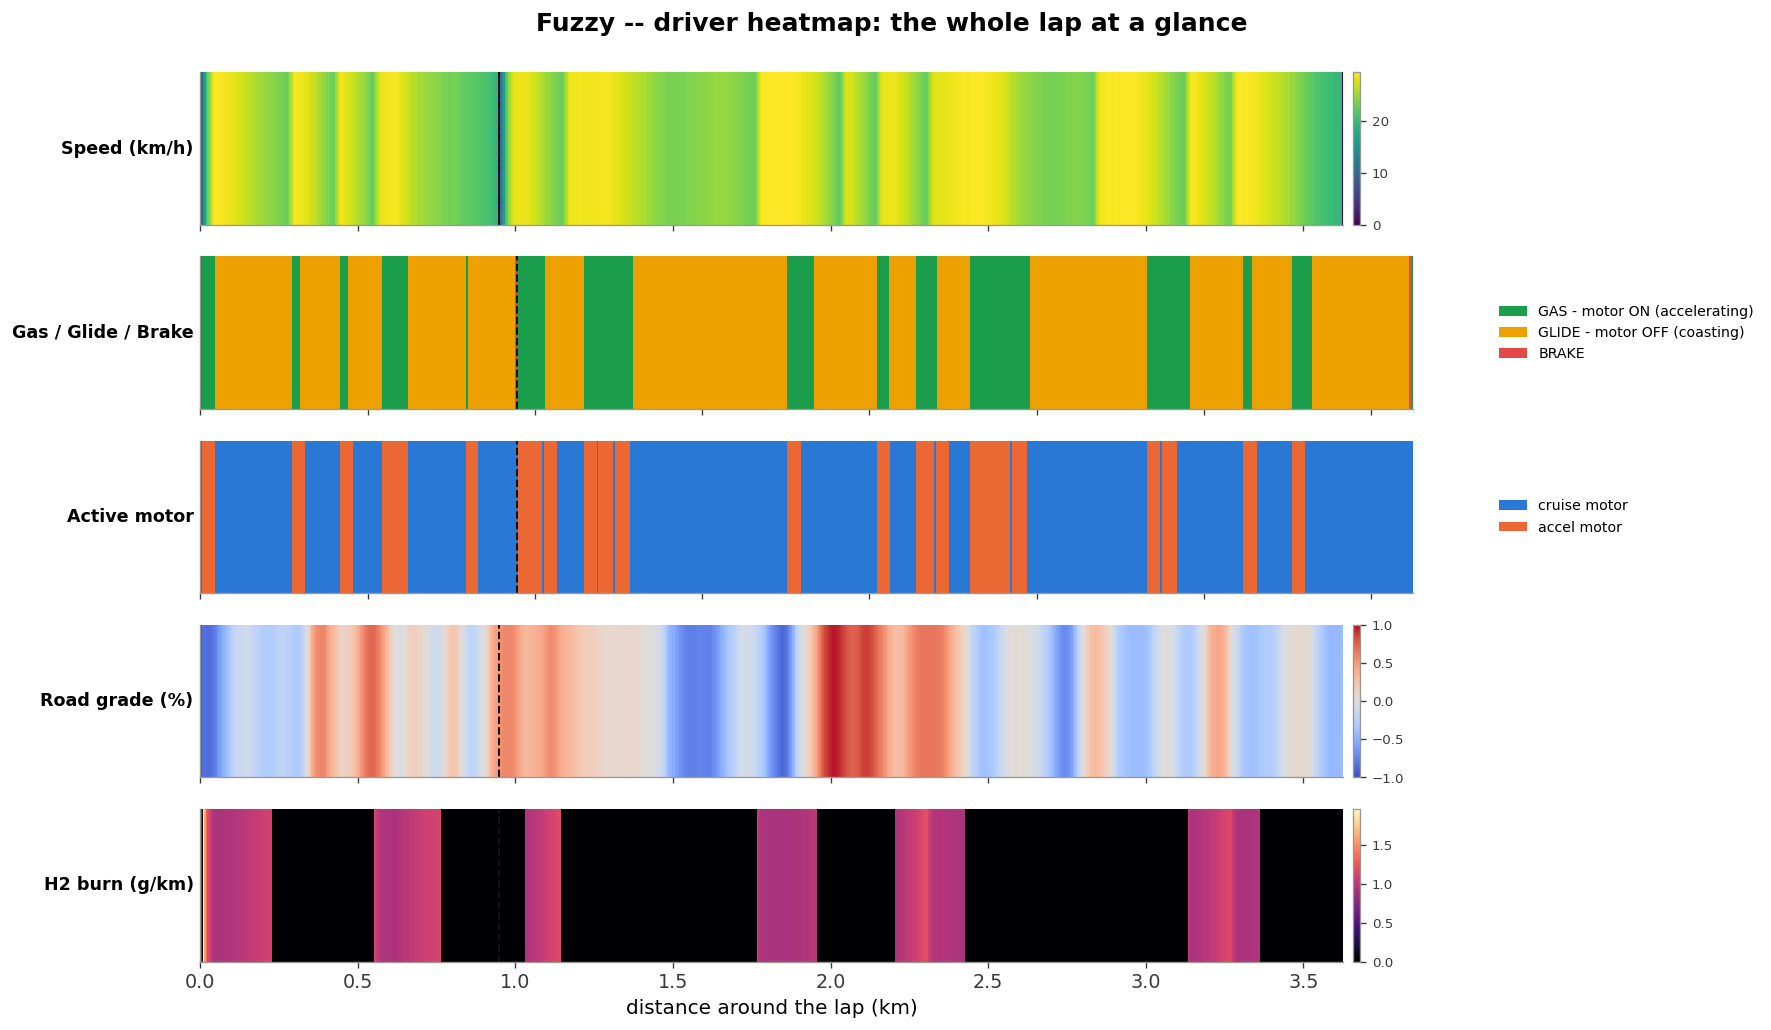

In [9]:
# ============ THE DRIVER HEATMAP =============================================
# One strip per channel, all sharing the lap-distance axis: everything the driver
# needs at a glance -- speed, the gas/glide command, which motor, the road grade,
# and the resulting hydrogen burn. Colour = value along the track.
s = steady.sort_values('lap_distance_km')
x = s.lap_distance_km.to_numpy()
xe = np.concatenate([[x[0]], (x[:-1] + x[1:]) / 2, [x[-1]]])   # cell edges

fc_flow_g_km = s.h2_flow_m3_s.to_numpy() * 1000.0 * config.H2_DENSITY_G_PER_L_STP * 3600.0 / np.clip(s.v_kmh.to_numpy(), 1, None)
motor_num = (s.active_motor == accel_motor.name).astype(int).to_numpy()   # 1 = accel motor, 0 = cruise

channels = [
    ('Speed (km/h)',        s.v_kmh.to_numpy(),   'viridis', None,  'continuous'),
    ('Gas / Glide / Brake', s.gas_glide_num.to_numpy(), 'phase', None, 'phase'),
    ('Active motor',        motor_num,            'motor', None,     'motor'),
    ('Road grade (%)',      s.grade_pct.to_numpy(), 'coolwarm', 'diverging', 'continuous'),
    ('H2 burn (g/km)',      fc_flow_g_km,         'magma',   None,   'continuous'),
]
phase_cmap = ListedColormap([PHASE_COLORS['glide'], PHASE_COLORS['gas'], PHASE_COLORS['brake']])
motor_cmap = ListedColormap([MOTOR_COLORS[cruise_motor.name], MOTOR_COLORS[accel_motor.name]])

fig, axes = plt.subplots(len(channels), 1, figsize=(15, 8.6), sharex=True)
for ax, (label, vals, cmap, kind, mode) in zip(axes, channels):
    v = vals.reshape(1, -1)
    if mode == 'phase':
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=phase_cmap, norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3))
    elif mode == 'motor':
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=motor_cmap, norm=BoundaryNorm([-0.5, 0.5, 1.5], 2))
    elif kind == 'diverging':
        mx = max(1.0, np.abs(vals).max())
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=cmap, norm=TwoSlopeNorm(0.0, -mx, mx))
    else:
        mesh = ax.pcolormesh(xe, [0, 1], v, cmap=cmap)
    ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=10.5, fontweight='bold')
    ax.grid(False)
    if mode not in ('phase', 'motor'):
        cb = fig.colorbar(mesh, ax=ax, pad=0.008, fraction=0.05); cb.ax.tick_params(labelsize=8)
    if sg2_lapkm is not None:
        ax.axvline(sg2_lapkm, color='#111111', ls='--', lw=1.2)
    ax.axvline(0, color='#6a3d9a', lw=1.6)
axes[-1].set_xlabel('distance around the lap (km)')
# legends for the two categorical strips
axes[1].legend(handles=[Patch(facecolor=PHASE_COLORS[p], label=PHASE_LABEL[p]) for p in ['gas', 'glide', 'brake']],
               loc='center left', bbox_to_anchor=(1.06, 0.5), frameon=False, fontsize=8.5)
axes[2].legend(handles=[Patch(facecolor=MOTOR_COLORS[cruise_motor.name], label='cruise motor'),
                        Patch(facecolor=MOTOR_COLORS[accel_motor.name], label='accel motor')],
               loc='center left', bbox_to_anchor=(1.06, 0.5), frameon=False, fontsize=8.5)
fig.suptitle(TITLE + ' -- driver heatmap: the whole lap at a glance', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(); plt.show()


## Speed heatmap - every lap
Confirms the strategy repeats lap to lap (lap 1 has no stop-and-go 1 at the standing start).

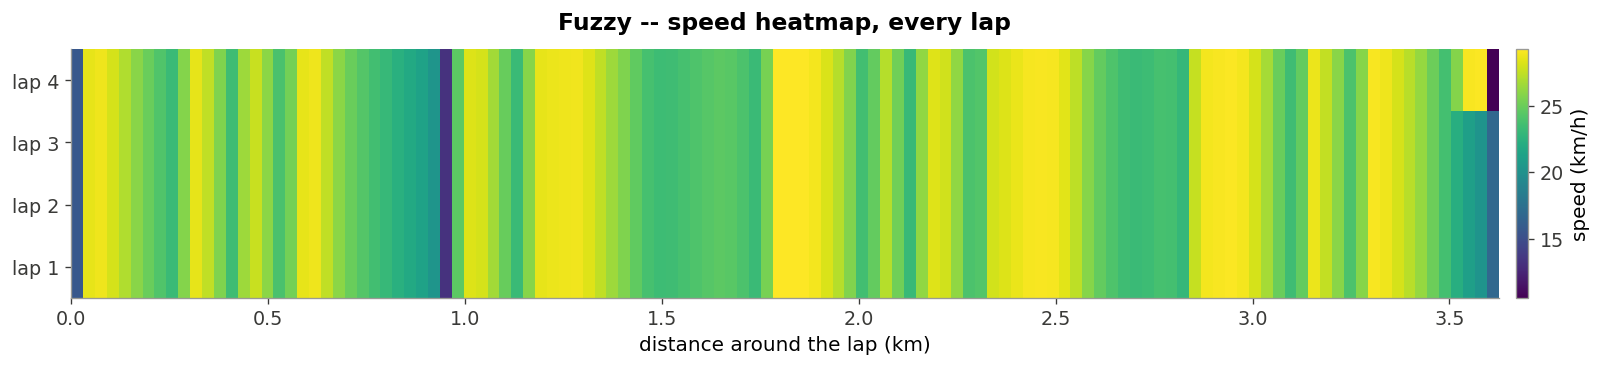

In [10]:
# 2-D heatmap: speed over (lap x distance-around-lap) -- shows the strategy is
# repeatable lap to lap (lap 1 differs: no stop-and-go 1 at the standing start).
nb = 120
bins = np.linspace(0, df.lap_distance_km.max(), nb + 1)
mid = 0.5 * (bins[:-1] + bins[1:])
laps = sorted(df.lap.unique())
grid_speed = np.full((len(laps), nb), np.nan)
for r, lap in enumerate(laps):
    d = df[df.lap == lap]
    idx = np.clip(np.digitize(d.lap_distance_km, bins) - 1, 0, nb - 1)
    for b in range(nb):
        sel = idx == b
        if sel.any():
            grid_speed[r, b] = d.v_kmh.to_numpy()[sel].mean()
fig, ax = plt.subplots(figsize=(15, 3.2))
im = ax.pcolormesh(bins, np.arange(len(laps) + 1), grid_speed, cmap='viridis')
ax.set_yticks(np.arange(len(laps)) + 0.5); ax.set_yticklabels(['lap ' + str(l) for l in laps])
ax.set_xlabel('distance around the lap (km)'); ax.set_title(TITLE + ' -- speed heatmap, every lap')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01); cb.set_label('speed (km/h)')
plt.tight_layout(); plt.show()


## Elevation, slope & where the accel motor works

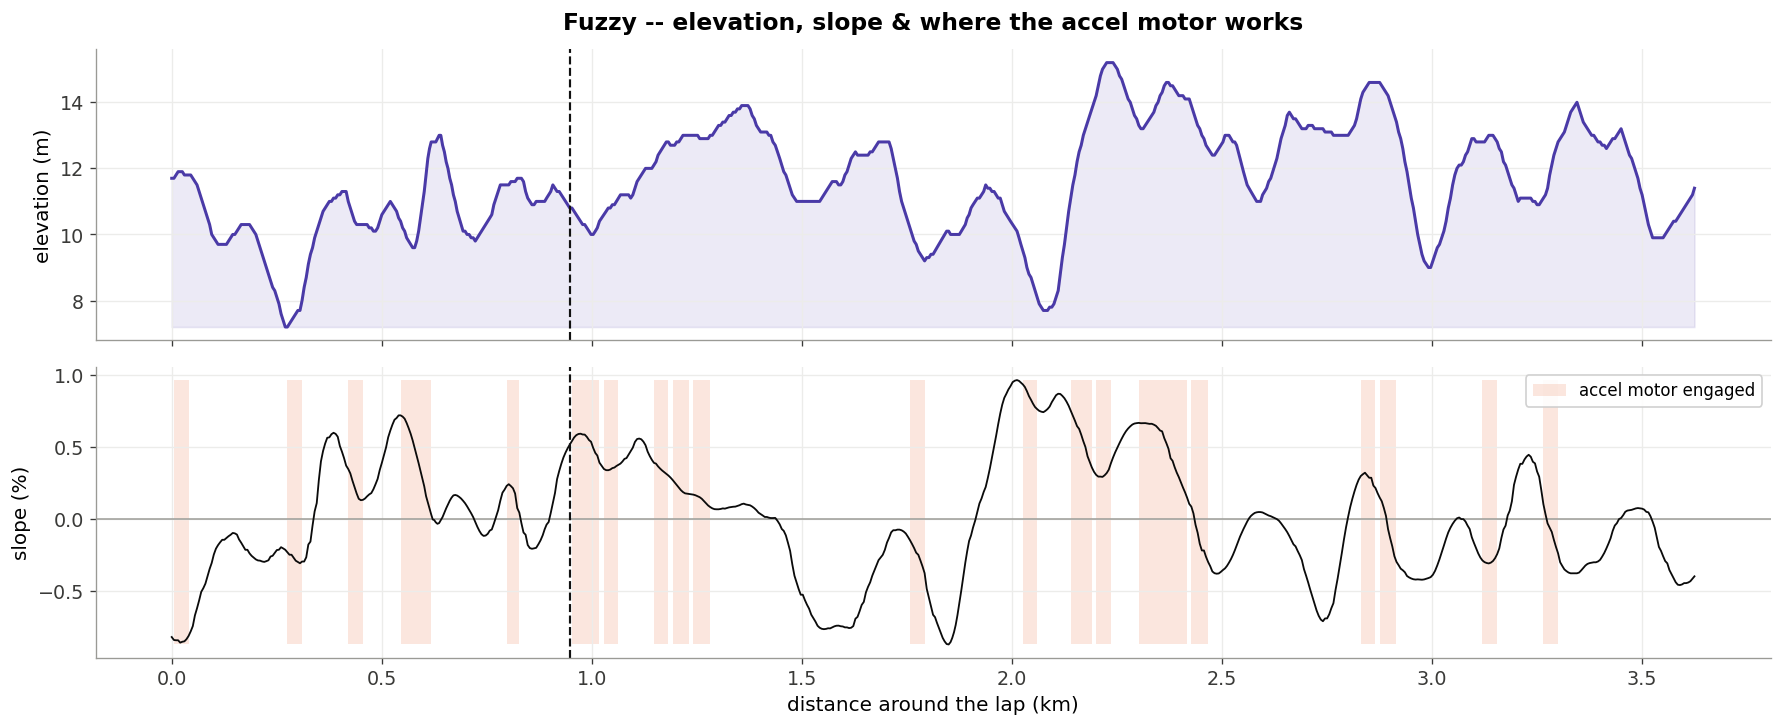

In [11]:
fig, (axa, axb) = plt.subplots(2, 1, figsize=(15, 6.2), sharex=True)
axa.plot(steady.lap_distance_km, steady.altitude_m, color='#4a3aa7', lw=1.8)
axa.fill_between(steady.lap_distance_km, steady.altitude_m.min(), steady.altitude_m, color='#4a3aa7', alpha=0.10)
axa.set_ylabel('elevation (m)'); axa.set_title(TITLE + ' -- elevation, slope & where the accel motor works')
axb.axhline(0, color='#9a9a95', lw=0.9)
axb.plot(steady.lap_distance_km, steady.grade_pct, color='#0b0b0b', lw=1.1)
mask = (steady.active_motor == accel_motor.name).to_numpy()
axb.fill_between(steady.lap_distance_km, steady.grade_pct.min(), steady.grade_pct.max(),
                 where=mask, color='#eb6834', alpha=0.16, lw=0, label='accel motor engaged')
axb.set_ylabel('slope (%)'); axb.set_xlabel('distance around the lap (km)')
axb.legend(loc='upper right', framealpha=0.9)
if sg2_lapkm is not None:
    for ax in (axa, axb):
        ax.axvline(sg2_lapkm, color='#111111', ls='--', lw=1.3)
plt.tight_layout(); plt.show()


## Strategy zones - the lap divided up
The lap split into contiguous zones by dominant action (gas/glide) and motor - a plain cheat-sheet of the lap.

Lap divided into 11 strategy zones:


,from_km,to_km,action,motor,avg_kmh
0,0.0,0.9,GLIDE,cruise,25.3
1,0.9,1.0,GAS,accel,22.7
2,1.0,1.2,GLIDE,cruise,25.7
3,1.2,1.4,GAS,accel,28.5
4,1.4,2.1,GLIDE,cruise,25.6
5,2.1,2.2,GLIDE,accel,26.3
6,2.2,2.4,GAS,accel,26.3
7,2.4,2.6,GAS,cruise,28.7
8,2.6,2.8,GLIDE,cruise,24.2
9,2.8,3.0,GAS,cruise,28.9


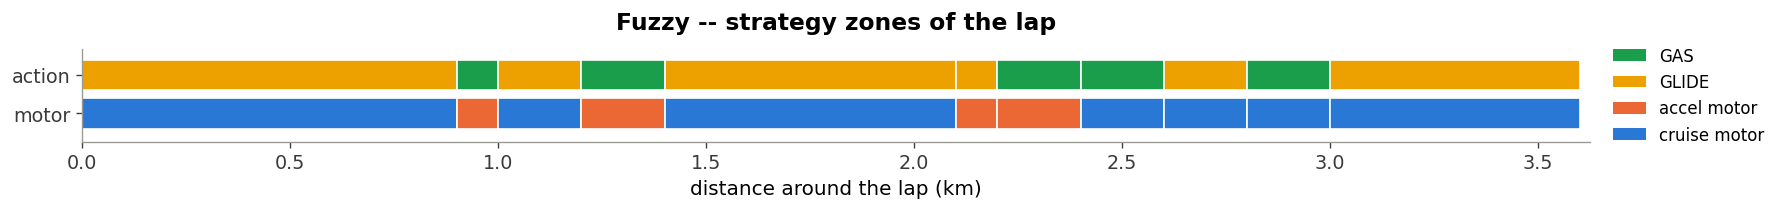

In [12]:
# Divide ONE lap into contiguous strategy zones: dominant action (gas/glide) and
# which motor, per ~150 m block -- a plain driver cheat-sheet of the lap.
block_m = 150.0
s = steady.sort_values('lap_distance_km').reset_index(drop=True)
blk = (s.lap_distance_km * 1000 // block_m).astype(int)
rows = []
for b, g in s.groupby(blk):
    ph = g.drive_phase.mode().iloc[0]
    mot = g.active_motor.mode().iloc[0]
    rows.append({'from_km': round(g.lap_distance_km.min(), 2), 'to_km': round(g.lap_distance_km.max(), 2),
                 'action': ph.upper(), 'motor': 'accel' if mot == accel_motor.name else 'cruise',
                 'avg_kmh': round(g.v_kmh.mean(), 1), 'avg_grade': round(g.grade_pct.mean(), 1)})
zones = pd.DataFrame(rows)
# merge consecutive blocks with the same (action, motor) into zones
zones['grp'] = ((zones.action != zones.action.shift()) | (zones.motor != zones.motor.shift())).cumsum()
merged = zones.groupby('grp').agg(from_km=('from_km', 'min'), to_km=('to_km', 'max'),
                                  action=('action', 'first'), motor=('motor', 'first'),
                                  avg_kmh=('avg_kmh', 'mean')).round(1).reset_index(drop=True)
print('Lap divided into', len(merged), 'strategy zones:')
display(merged)

fig, ax = plt.subplots(figsize=(15, 1.9))
for _, z in merged.iterrows():
    ax.barh(0, z.to_km - z.from_km, left=z.from_km, height=0.6,
            color=PHASE_COLORS['gas'] if z.action == 'GAS' else PHASE_COLORS['glide'],
            edgecolor='white')
    ax.barh(-0.75, z.to_km - z.from_km, left=z.from_km, height=0.6,
            color=MOTOR_COLORS[accel_motor.name] if z.motor == 'accel' else MOTOR_COLORS[cruise_motor.name],
            edgecolor='white')
ax.set_yticks([0, -0.75]); ax.set_yticklabels(['action', 'motor'])
ax.set_ylim(-1.3, 0.5); ax.set_xlim(0, steady.lap_distance_km.max()); ax.grid(False)
ax.set_xlabel('distance around the lap (km)'); ax.set_title(TITLE + ' -- strategy zones of the lap')
ax.legend(handles=[Patch(facecolor=PHASE_COLORS['gas'], label='GAS'), Patch(facecolor=PHASE_COLORS['glide'], label='GLIDE'),
                   Patch(facecolor=MOTOR_COLORS[accel_motor.name], label='accel motor'),
                   Patch(facecolor=MOTOR_COLORS[cruise_motor.name], label='cruise motor')],
          loc='center left', bbox_to_anchor=(1.005, 0.5), frameon=False)
plt.tight_layout(); plt.show()


## Whole-attempt efficiency - the headline result

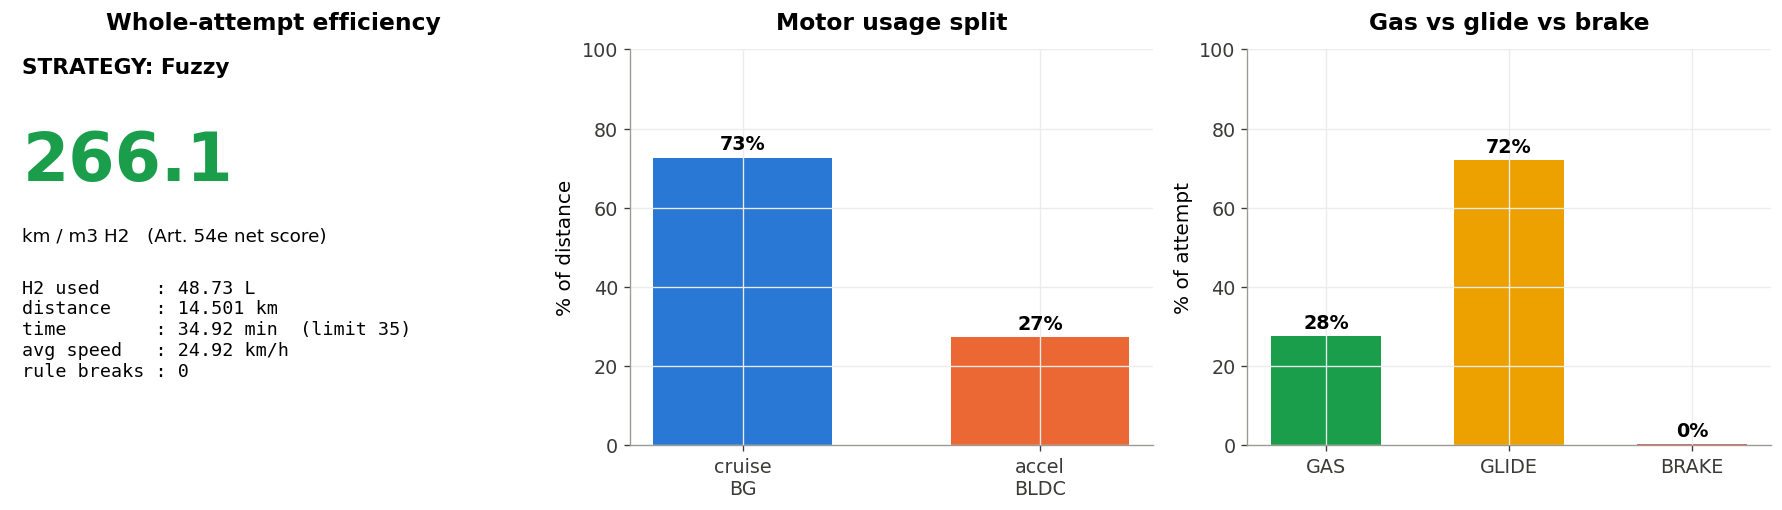

In [13]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 4.4))
# KPI card
ax0.axis('off')
kpi = ['STRATEGY: ' + TITLE, '', 'Art. 54e score', str(S['score_km_per_m3']) + '  km / m3 H2', '',
       'H2 used     : ' + str(S['h2_litres']) + ' L', 'distance    : ' + str(S['distance_km']) + ' km',
       'time        : ' + str(S['time_min']) + ' min  (limit 35)', 'avg speed   : ' + str(S['avg_speed_kmh']) + ' km/h',
       'rule breaks : ' + str(S['rule_violations'])]
ax0.text(0.02, 0.98, kpi[0], fontsize=13, fontweight='bold', va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.80, S['score_km_per_m3'], fontsize=40, fontweight='bold', color='#1a9e4b', va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.55, 'km / m3 H2   (Art. 54e net score)', fontsize=11, va='top', transform=ax0.transAxes)
ax0.text(0.02, 0.42, '\n'.join(kpi[5:]), fontsize=11, va='top', family='monospace', transform=ax0.transAxes)
ax0.set_title('Whole-attempt efficiency')
# motor share
sh = df.active_motor.value_counts(normalize=True) * 100
ax1.bar([('accel\n' if n == accel_motor.name else 'cruise\n') + n.split()[0] for n in sh.index],
        sh.values, color=[MOTOR_COLORS[n] for n in sh.index], width=0.6)
for i, v in enumerate(sh.values):
    ax1.text(i, v + 2, str(round(v)) + '%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100); ax1.set_ylabel('% of distance'); ax1.set_title('Motor usage split')
# phase share
order = [p for p in ['gas', 'glide', 'brake'] if p in df.drive_phase.values]
pc = df.drive_phase.value_counts(normalize=True).reindex(order) * 100
ax2.bar([p.upper() for p in order], pc.values, color=[PHASE_COLORS[p] for p in order], width=0.6)
for i, v in enumerate(pc.values):
    ax2.text(i, v + 2, str(round(v)) + '%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100); ax2.set_ylabel('% of attempt'); ax2.set_title('Gas vs glide vs brake')
plt.tight_layout(); plt.show()


## Servo motor-switch time (0.5 s) - sensitivity

The two-motor powertrain needs a physical **servo** to hand the drive between the acceleration
motor and the cruise motor. The digital twin now models that delay as `config.MOTOR_SWITCH_TIME_S`
(default **0.5 s**, configurable 0.5 / 1 / 2 / 3 s): while the servo is mid-swap the deliverable
traction is throttled (ramping `MOTOR_SWITCH_MIN_POWER_FRAC` -> 1.0 over the window), so every
accel<->cruise handoff can cost a little speed, time and hydrogen.

The cell below re-runs **this strategy's own plan** with the switch OFF vs ON to isolate its cost.
For the optimised plan the effect is **tiny**: of the ~15 handoffs per attempt, roughly half happen
while the car is stopped at a stop-and-go (the servo swaps during the mandatory dwell) and the rest
land at gas->glide transitions where power demand is already near zero - so a well-timed run barely
feels the servo. (Under driver *timing* errors the same switches become costly - see the `margin/`
driver-error study.)

> The **absolute** numbers below come from re-simulating through the *current* fuel-cell curve, so
> they differ from the headline above (which loads the committed telemetry made on an earlier FC
> curve). The committed telemetry is left untouched - only the OFF-vs-ON **delta** is meaningful here.


In [14]:
# ============ SERVO MOTOR-SWITCH SENSITIVITY (0.5 s) ==========================
# Re-run THIS strategy's plan through the current physics with the switch OFF vs ON.
# The committed telemetry loaded above is NOT modified; the switch-on run is saved to a new csv.
from digital_twin import track as _tm, simulate as _sim, weather as _wm, telemetry as _telm
import margin.driver_sim as _ds

MODEL_KEY = 'fuzzy'
_profile = _tm.build_racing_line_profile(save=False)
_lap = _profile['distance_km'].iloc[-1]
_full = _sim.build_full_attempt_track(_profile)
_sc = _wm.SCENARIOS['typical_january']
_vt, _vc = _ds.reconstruct_setpoints(MODEL_KEY, _full, _lap)   # this strategy's UNCHANGED setpoints

def _run_switch(sw_s):
    config.MOTOR_SWITCH_TIME_S = sw_s
    t = _sim.simulate(_full, _sc, motor=None, fc=fc,
                      accel_motor=accel_motor, cruise_motor=cruise_motor,
                      motor_select_mode='rule', v_target_kmh=_vt, v_coast_kmh=_vc, cruise_converter=pt.load_converters()[config.CRUISE_CONVERTER_NAME])
    dist = t.s_m.iloc[-1] / 1000.0; h2 = t.h2_cumulative_m3.iloc[-1]
    acc = t.accessory_energy_cumulative_j.iloc[-1]
    nsw = int((t.active_motor.values[1:] != t.active_motor.values[:-1]).sum())
    return dict(score=round(_telm.h2_score_km_per_m3(dist, h2, accessory_energy_j=acc), 1),
                time_min=round(t.t_s.iloc[-1] / 60.0, 2), h2_L=round(h2 * 1000, 2), switches=nsw), t

_off, _ = _run_switch(0.0)
_on, _tel_on = _run_switch(0.5)
config.MOTOR_SWITCH_TIME_S = 0.5   # restore the modelled default

print(f'{TITLE} servo-switch sensitivity (current-physics re-sim, {_on["switches"]} handoffs):')
print(f'  switch OFF (0.0 s): score {_off["score"]:6.1f}  time {_off["time_min"]:.2f} min  H2 {_off["h2_L"]:.2f} L')
print(f'  switch ON  (0.5 s): score {_on["score"]:6.1f}  time {_on["time_min"]:.2f} min  H2 {_on["h2_L"]:.2f} L')
print(f'  --> servo cost   : dscore {_on["score"]-_off["score"]:+.1f}   dtime {_on["time_min"]-_off["time_min"]:+.2f} min   dH2 {_on["h2_L"]-_off["h2_L"]:+.2f} L')

_out = os.path.join('notebooks', MODEL_KEY, MODEL_KEY + '_switch05_telemetry.csv')
_tel_on.to_csv(_out, index=False)   # NEW file, does not overwrite committed telemetry
print('saved 0.5 s switch-on telemetry ->', _out)


Fuzzy servo-switch sensitivity (current-physics re-sim, 15 handoffs):
  switch OFF (0.0 s): score  210.4  time 35.36 min  H2 63.05 L
  switch ON  (0.5 s): score  210.4  time 35.36 min  H2 63.05 L
  --> servo cost   : dscore +0.0   dtime +0.00 min   dH2 +0.00 L
saved 0.5 s switch-on telemetry -> notebooks/fuzzy/fuzzy_switch05_telemetry.csv


## Hybrid fuel-cell + supercapacitor energy system  (SEM Art. 56c compliant)

The fuel cell runs in **parallel with a 3-series Maxwell BMOD0058 supercapacitor** feeding the
DC-DC converter. The FC is held at its **efficient operating point (558 W, 62%)** and the supercap
absorbs the launch peaks / returns energy during cruise; hydrogen is billed off the FC energy at
62% via Art. 54e's joulemeter formula. Per **SEM Art. 56c(iii)** the supercap voltage **after** the
run must be **>= before** it: the bank starts a little below full (headroom, so it can never
overcharge past V_max), and because the FC is idle most of the run it tops the cap back up to the
**start voltage** using that spare capacity -- so `V_end == V_start` at no extra run time. The lower
panel shows the supercap voltage returning exactly to its start line and never touching V_max.


Fuzzy hybrid energy system (SEM Art. 56c compliant):
  Supercap 3S : 19.3 F, 48 V max, 66 mOhm, 6.19 Wh
  FC op point : 558 W @ 62% efficiency   |   FC duty cycle: 30%
  SEM 56c(iii): Vstart 45.54 V  ->  Vend 45.54 V   (Vend >= Vstart: True)
                peak 47.90 V < Vmax 48 V (no overcharge)   |   post-run recharge: 6.3 s
  H2 (FC 62%) : 48.73 L   ->   Art.54e score 266.1 km/m3


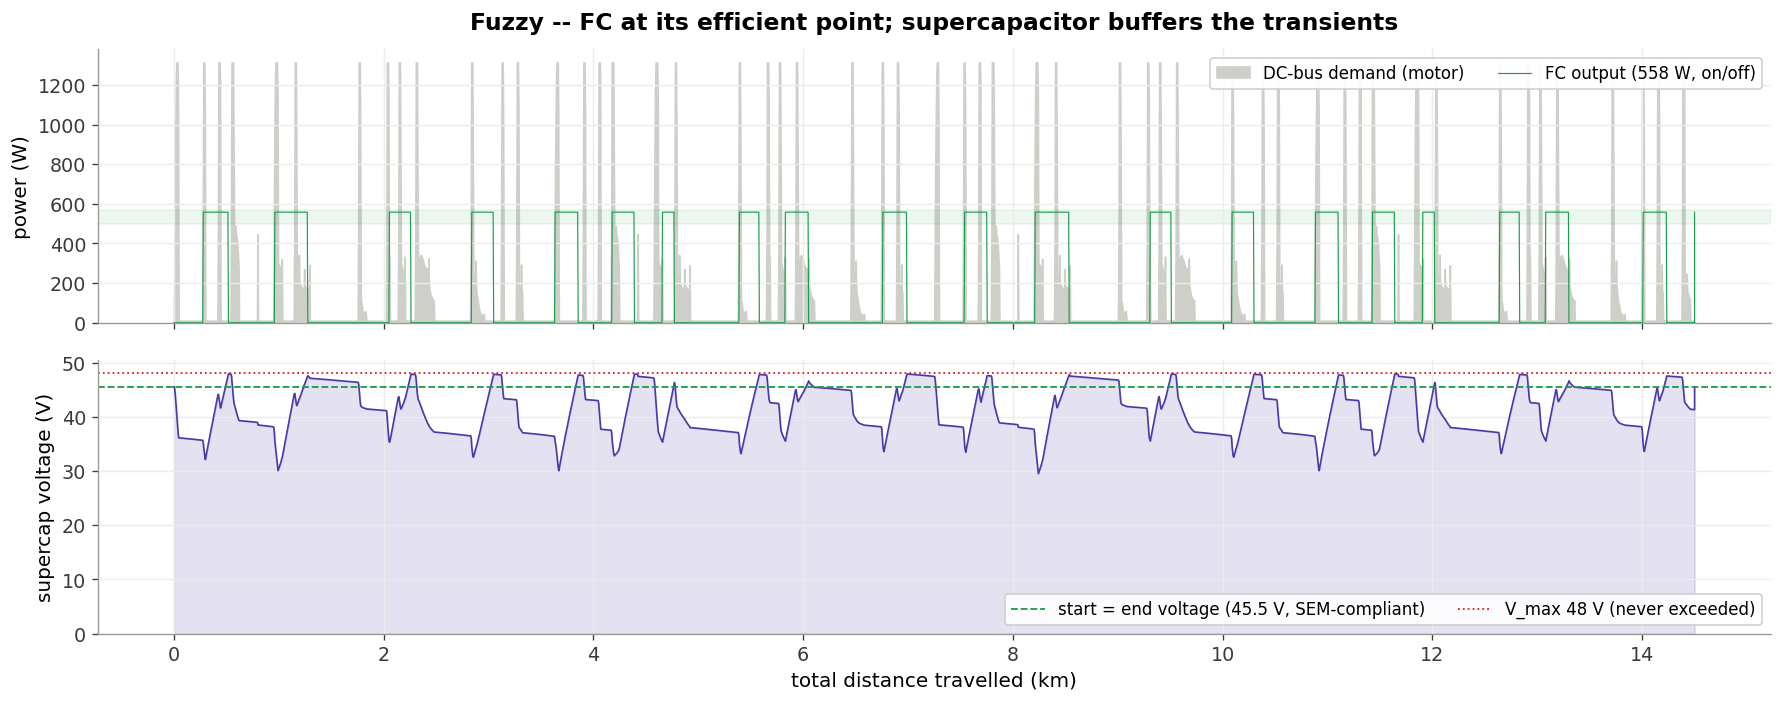

In [15]:
# ============ HYBRID FC + SUPERCAPACITOR ENERGY SYSTEM (SEM Art. 56c) =========
from digital_twin import hybrid_energy as _he
_D = df
_spec = _he.supercap_specs()
_duty = (_D.p_fc_out_w > 0).mean() * 100
_vmax = config.SUPERCAP_MODULE_V * config.SUPERCAP_N_SERIES
_vs, _ve = _D.supercap_v_start.iloc[0], _D.supercap_v_end.iloc[0]
print(f'{TITLE} hybrid energy system (SEM Art. 56c compliant):')
print(f'  Supercap 3S : {_spec["C"]:.1f} F, {_vmax:.0f} V max, {_spec["ESR"]*1000:.0f} mOhm, {_spec["E_max"]/3600:.2f} Wh')
print(f'  FC op point : {config.FC_HYBRID_OP_POWER_W:.0f} W @ {config.FC_HYBRID_EFF*100:.0f}% efficiency   |   FC duty cycle: {_duty:.0f}%')
print(f'  SEM 56c(iii): Vstart {_vs:.2f} V  ->  Vend {_ve:.2f} V   (Vend >= Vstart: {bool(_ve >= _vs - 1e-6)})')
print(f'                peak {_D.supercap_voltage_v.max():.2f} V < Vmax {_vmax:.0f} V (no overcharge)   |   post-run recharge: {_D.supercap_recharge_s.iloc[0]:.1f} s')
print(f'  H2 (FC 62%) : {S["h2_litres"]} L   ->   Art.54e score {S["score_km_per_m3"]} km/m3')

fig, (axA, axB) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axA.fill_between(_D.distance_km, 0, _D.p_fc_elec_w, color='#cfcfca', label='DC-bus demand (motor)')
axA.plot(_D.distance_km, _D.p_fc_out_w, color='#1a9e4b', lw=0.7, label=f'FC output ({config.FC_HYBRID_OP_POWER_W:.0f} W, on/off)')
axA.axhspan(config.FC_HYBRID_BAND_W[0], config.FC_HYBRID_BAND_W[1], color='#1a9e4b', alpha=0.08)
axA.set_ylabel('power (W)'); axA.set_ylim(0, None); axA.legend(loc='upper right', ncol=2, framealpha=0.9)
axA.set_title(f'{TITLE} -- FC at its efficient point; supercapacitor buffers the transients')
axB.fill_between(_D.distance_km, 0, _D.supercap_voltage_v, color='#4a3aa7', alpha=0.15)
axB.plot(_D.distance_km, _D.supercap_voltage_v, color='#4a3aa7', lw=1.0)
axB.axhline(_vs, color='#1a9e4b', ls='--', lw=1.1, label=f'start = end voltage ({_vs:.1f} V, SEM-compliant)')
axB.axhline(_vmax, color='#d62728', ls=':', lw=1.1, label=f'V_max {_vmax:.0f} V (never exceeded)')
axB.set_ylabel('supercap voltage (V)'); axB.set_xlabel('total distance travelled (km)')
axB.set_ylim(0, _vmax * 1.05); axB.legend(loc='lower right', framealpha=0.9, ncol=2)
plt.tight_layout(); plt.show()


## Takeaway
The strategy above is the **most efficient run that still completes the four laps inside the 35-minute limit with zero rule violations**, using the new **SZFC-1000** fuel cell and the two-motor split. The driver heatmap and the strategy-zone chart are the deliverables to hand to the driver: *where to gas, where to glide, and which motor is doing the work* at every point of the lap. The Art. 54e score (km per m3 of H2) is the number to compare against the other strategies (GA / PSO / CMA-ES / DP) and across the fuzzy-vs-MPC choice.